Class RandomWalk represents a grid of size $1\times N$. 

For each vertex $x$ of the grid we generate a uniform random variable on the interval $[0.1,0.9]$ -- $w[x]$. 

For each vertex we can pick two actions $a[x]\in \{0,1\}$. 

If action $a[x]=0$ is chosen then the random walk moves to the right with probability $\frac{w[x+1]}{w[x-1]+w[x+1]}$ and to the left with probability $\frac{w[x-1]}{w[x-1]+w[x+1]}$.

If action $a[x]=1$ is chosen then the random walk moves to the right with probability $\frac{w[x-1]}{w[x-1]+w[x+1]}$ and to the left with probability $\frac{w[x+1]}{w[x-1]+w[x+1]}$. 

$N$ -- size of grid 
$x$ -- initial position of the random walk. If not given then a random value on $[1,N-1]$ is assigned

In [176]:
import numpy as np 
import math 
import matplotlib.pyplot as plt


class RandomWalk:

    def __init__(self, N): 
        self.N = N
        #self.w = np.random.uniform(low=0.1, high=0.9, size=N)
        self.w = np.ones(N)
        print(self.w)
        
        
    def is_state_terminal(self,x):
        return x == 0 or x == self.N-1 
    
    def random_start(self):
        return np.random.randint(0, self.N) 

    def next_step(self,  x, a):
        """
        If a=1 then it jumps to the right with probability w[x+1]/(w[x-1]+w[x+1]) and left otherwise. 
        If a=0 then it jumps to the right with probability w[x-1]/(w[x-1]+w[x+1]) and left otherwise. 

        :param a: action with possible values 0 or 1 

        return: state and reward 
        
        """
        if self.is_state_terminal(x):
            return (x,0) 
        total = self.w[x+1]+self.w[x-1]
        if a == 1:
            p = self.w[x+1]/total
        else:
            p = self.w[x-1]/total 
        
        if p>np.random.rand():
            x+=1
        else:
            x-=1    
       
        reward = 1 if x == self.N-1 else 0 
        return (x,reward) 
     
    


class MC that applied Monte-Carlo for policy evaluation

In [177]:
class MC:
    
    def __init__(self, rw, M,beta=1):

        self.rw = rw 
        self.M = M
        self.N = rw.N
        
        self.pi = np.zeros(self.N,dtype=int)
        self.Q = np.zeros((self.N, 2))
        self.l = np.zeros((self.N, 2))
        self.beta = beta 
        
        self.V_running = []
        for x in range(rw.N):
            self.V_running.append([]) 


    def evaluate_policy(self):
         
         for i in range(self.N):
            if self.Q[i,0]> self.Q[i,1]:
                self.pi[i] = 0 
            else:
                self.pi[i] = 1    

    def generate_episode(self,x,a):

        s = []
        a0 = a
        while not self.rw.is_state_terminal(x):
            (state,reward) = self.rw.next_step(x,a0)
            s.append((x,reward)) 
            x = state 
            a0 = self.pi[x]
        return s     

    def run(self):
    
    
        for i in range(self.M): 
            self.evaluate_policy()
            x = np.random.randint (1,self.N-1)
            a = np.random.randint(2)
            episode = self.generate_episode(x,a)
            T = len(episode)
            g = 0
            for j in range(T-1, 0, -1):
                (x,reward) = episode[j]
                g=self.beta*g+reward
                self.l[x,self.pi[x]]+=1 
                self.Q[x,self.pi[x]]+= (g-self.Q[x,self.pi[x]])/self.l[x,self.pi[x]]
                self.V_running[x].append(self.Q[x,0] if self.Q[x,0]> self.Q[x,1] else self.Q[x,1])
            (x,reward) = episode[0]    
            g=g*self.beta+reward
            self.l[x,a]+=1 
            self.Q[x,a] += (g-self.Q[x,a])/self.l[x,a]    
            self.V_running[x].append(self.Q[x,0] if self.Q[x,0]> self.Q[x,1] else self.Q[x,1])
            v = np.zeros(self.N)
        for i in range(self.N):
            v[i] = self.Q[i,0] if self.Q[i,0]> self.Q[i,1] else self.Q[i,1]
        print(v)
        print(self.pi)
   

Class SARSA for testing SARSA

In [178]:
class SARSA:
    
    def __init__(self, rw, M,alpha, beta=1):

        self.rw = rw 
        self.M = M
        self.N = rw.N
        self.alpha = alpha 
        
        self.Q = np.zeros((self.N, 2))
        self.beta = beta 
        
        self.V_running = []
        for x in range(rw.N):
            self.V_running.append([]) 

    def alpha_t(self, x, fixed):
        
        return self.alpha  #if fixed else self.alpha/math.pow(1+len(self.V_running[x]),0.9)
    

    def policy(self,x):
        a = 0 if self.Q[x,0]> self.Q[x,1] else 1 
        return a


    def run(self, fixed):
    
    
        for i in range(self.M): 
            x = np.random.randint (1,self.N-1)
            while not self.rw.is_state_terminal(x):
                a = self.policy(x)
                (state,reward) = self.rw.next_step(x,a)
                self.Q[x,a]+= self.alpha_t(x,fixed)*(reward+self.beta*(self.Q[state,self.policy(state)]-self.Q[x,a]))
                self.V_running[x].append(self.Q[x,0] if self.Q[x,0]> self.Q[x,1] else self.Q[x,1])
                x = state 

        v = np.zeros(self.N)
        for i in range(self.N):
            v[i] = self.Q[i,0] if self.Q[i,0]> self.Q[i,1] else self.Q[i,1]
        print(v)
        

[1. 1. 1. 1. 1. 1.]
[0.         0.20045405 0.40254626 0.60165032 0.80041442 0.        ]
[1 0 0 0 1 1]
[0.         0.20149765 0.39495031 0.59186405 0.79336764 0.        ]


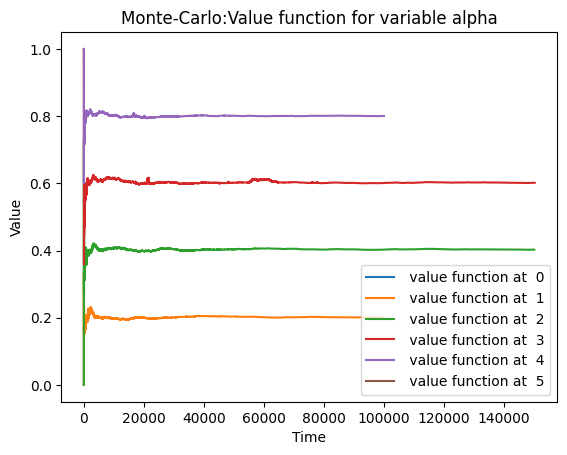

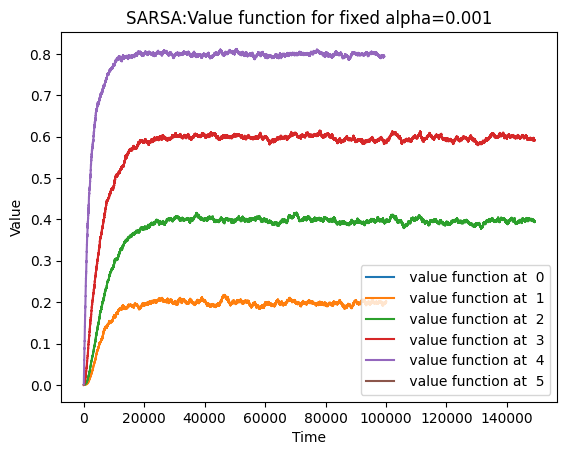

In [179]:
def main():

    beta = 1
    alpha = 0.001
    M = 100000 
    N = 6 
    rw = RandomWalk(N)
    mc = MC(rw,M,beta)
    mc.run()
    
    #### MC with fixed alpha

    
    plt.figure(1)
    for x in range(N):
        plt.plot(mc.V_running[x], label=" value function at  "+str(x))

    # Plot value functions in time 
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('Monte-Carlo:Value function for variable alpha')
    plt.legend()

    sarsa = SARSA(rw,M,alpha,beta)
    sarsa.run(True)
    #### SARSA with fixed alpha

    
    plt.figure(2)
    for x in range(N):
        plt.plot(sarsa.V_running[x], label=" value function at  "+str(x))

    # Plot value functions in time 
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('SARSA:Value function for fixed alpha='+str(alpha))
    plt.legend()

    

if __name__ == "__main__":
    # Call the main function
    main()